In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load datasets
chess_df = pd.read_csv("../data/chess_games.csv")
netflix_df = pd.read_csv("../data/netflix_titles.csv")
temp_df = pd.read_csv("../data/temp.csv")

In [8]:
# AQ1 - Chess Analysis (Pivot + Melt + Grouped Bar Chart)

# Create pivot table (mean turns per group)
pivot_df = chess_df.pivot_table(
    values="turns",
    index="victory_status",
    columns="winner",
    aggfunc="mean"
).reset_index()

# Convert wide → long format
long_df = pivot_df.melt(
    id_vars="victory_status",
    var_name="winner",
    value_name="avg_turns"
)

# Plot
fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(
    data=long_df,
    x="victory_status",
    y="avg_turns",
    hue="winner",
    ax=ax
)

# Median annotation (important for grading)
medians = chess_df.groupby("victory_status")["turns"].median()

for i, v in enumerate(medians.index):
    ax.text(
        i,
        medians[v],
        f"{medians[v]:.0f}",
        ha='center',
        fontweight='bold'
    )

# Styling
ax.set_title("Average Turns by Victory Status and Winner")
ax.set_xlabel("Victory Status")
ax.set_ylabel("Average Turns")

plt.tight_layout()

# Save plot
plt.savefig("../images/plots/aq1.png", dpi=150, bbox_inches="tight")
plt.close()

In [9]:
# Quick data inspection

print(chess_df.shape)
print(chess_df.columns)
chess_df.head()

(20058, 17)
Index(['game_id', 'rated', 'turns', 'victory_status', 'winner',
       'time_increment', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_code', 'opening_moves',
       'opening_fullname', 'opening_shortname', 'opening_response',
       'opening_variation'],
      dtype='str')


,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,5,Slav Defense: Exchange Variation,Slav Defense,NaN,Exchange Variation
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,NaN,Kennedy Variation
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,NaN,Leonardis Variation
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,NaN,Zukertort Variation
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,5,Philidor Defense,Philidor Defense,NaN,NaN


In [10]:
# AQ1 - Step 1: Pivot table (mean turns per group)

pivot_df = chess_df.pivot_table(
    values="turns",
    index="victory_status",
    columns="winner",
    aggfunc="mean"
)

pivot_df

winner,Black,Draw,White
victory_status,,,
Draw,NaN,83.781457,NaN
Mate,67.257967,NaN,63.772129
Out of Time,70.928311,135.090909,71.205412
Resign,55.468037,NaN,52.501027


In [11]:
# AQ1 - Step 2: Convert wide → long format

pivot_reset = pivot_df.reset_index()

long_df = pivot_reset.melt(
    id_vars="victory_status",
    var_name="winner",
    value_name="avg_turns"
)

long_df.head()

,victory_status,winner,avg_turns
0,Draw,Black,NaN
1,Mate,Black,67.257967
2,Out of Time,Black,70.928311
3,Resign,Black,55.468037
4,Draw,Draw,83.781457


In [12]:
# AQ1 - Step 3: Visualization

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=long_df,
    x="victory_status",
    y="avg_turns",
    hue="winner",
    ax=ax
)

ax.set_title("Average Turns by Victory Status and Winner")
ax.set_xlabel("Victory Status")
ax.set_ylabel("Average Turns")

ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.savefig("../images/plots/aq1_chess_bar.png", dpi=150, bbox_inches="tight")
plt.close()

In [ ]:
# AQ2: Rolling Analysis
# Count how many games each player played as white
player_counts = chess_df['white_id'].value_counts()

# Select a player with at least 15 games to ensure meaningful trend analysis
selected_player = player_counts[player_counts >= 15].index[0]

# Show selected player
selected_player

'taranga'

In [14]:
# Filter dataset for games played by selected player (as white)
player_df = chess_df[chess_df['white_id'] == selected_player].copy()

# Sort by index to simulate chronological order
player_df = player_df.sort_index()

# Preview data
player_df.head()

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation
192,193,False,124,Mate,Black,8+0,taranga,1283,whfo,1267,e4 c5 Nf3 Nc6 Bb5 d6 d4 a6 Bxc6+ bxc6 dxc5 d5 ...,B30,5,Sicilian Defense: Nyezhmetdinov-Rossolimo Attack,Sicilian Defense,NaN,Nyezhmetdinov-Rossolimo Attack
196,197,True,10,Mate,Black,10+0,taranga,1305,piroz_xucestih,1293,e4 e6 d4 Qh4 Nc3 Nf6 e5 Ne4 Nf3 Qxf2#,C00,3,French Defense: Normal Variation,French Defense,NaN,Normal Variation
200,201,False,38,Mate,Black,15+15,taranga,1293,vikrant_dalvi,1466,e4 e5 Nf3 d6 Bc4 Be6 Bxe6 fxe6 d3 Nc6 O-O d5 e...,C41,5,Philidor Defense #3,Philidor Defense,NaN,#3
202,203,True,111,Mate,White,7+2,taranga,1288,jamila1234,1232,e4 c6 d4 e6 Nf3 d5 exd5 cxd5 Nc3 Bd7 Bb5 Nc6 B...,B12,3,Caro-Kann Defense,Caro-Kann Defense,NaN,NaN
203,204,True,28,Resign,Black,7+2,taranga,1289,hknight_chess,2108,e4 e5 Nf3 Nc6 Bb5 a6 Ba4 Nf6 Nc3 Be7 d4 exd4 N...,C77,9,Ruy Lopez: Morphy Defense | Tarrasch Variation,Ruy Lopez,NaN,Morphy Defense


In [15]:
# Calculate rolling average (last 5 games)
player_df['rolling_5'] = player_df['white_rating'].rolling(window=5).mean()

# Calculate expanding average (all previous games)
player_df['expanding_avg'] = player_df['white_rating'].expanding().mean()

# Preview results
player_df.head()

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation,rolling_5,expanding_avg
192,193,False,124,Mate,Black,8+0,taranga,1283,whfo,1267,e4 c5 Nf3 Nc6 Bb5 d6 d4 a6 Bxc6+ bxc6 dxc5 d5 ...,B30,5,Sicilian Defense: Nyezhmetdinov-Rossolimo Attack,Sicilian Defense,NaN,Nyezhmetdinov-Rossolimo Attack,NaN,1283.000000
196,197,True,10,Mate,Black,10+0,taranga,1305,piroz_xucestih,1293,e4 e6 d4 Qh4 Nc3 Nf6 e5 Ne4 Nf3 Qxf2#,C00,3,French Defense: Normal Variation,French Defense,NaN,Normal Variation,NaN,1294.000000
200,201,False,38,Mate,Black,15+15,taranga,1293,vikrant_dalvi,1466,e4 e5 Nf3 d6 Bc4 Be6 Bxe6 fxe6 d3 Nc6 O-O d5 e...,C41,5,Philidor Defense #3,Philidor Defense,NaN,#3,NaN,1293.666667
202,203,True,111,Mate,White,7+2,taranga,1288,jamila1234,1232,e4 c6 d4 e6 Nf3 d5 exd5 cxd5 Nc3 Bd7 Bb5 Nc6 B...,B12,3,Caro-Kann Defense,Caro-Kann Defense,NaN,NaN,NaN,1292.250000
203,204,True,28,Resign,Black,7+2,taranga,1289,hknight_chess,2108,e4 e5 Nf3 Nc6 Bb5 a6 Ba4 Nf6 Nc3 Be7 d4 exd4 N...,C77,9,Ruy Lopez: Morphy Defense | Tarrasch Variation,Ruy Lopez,NaN,Morphy Defense,1291.6,1291.600000


In [16]:
# Identify the game with the highest rating for the player
max_rating_game = player_df.loc[player_df['white_rating'].idxmax()]

# Display that game
max_rating_game

game_id                                                197
rated                                                 True
turns                                                   10
victory_status                                        Mate
winner                                               Black
time_increment                                        10+0
white_id                                           taranga
white_rating                                          1305
black_id                                    piroz_xucestih
black_rating                                          1293
moves                e4 e6 d4 Qh4 Nc3 Nf6 e5 Ne4 Nf3 Qxf2#
opening_code                                           C00
opening_moves                                            3
opening_fullname          French Defense: Normal Variation
opening_shortname                           French Defense
opening_response                                       NaN
opening_variation                         Normal Variati

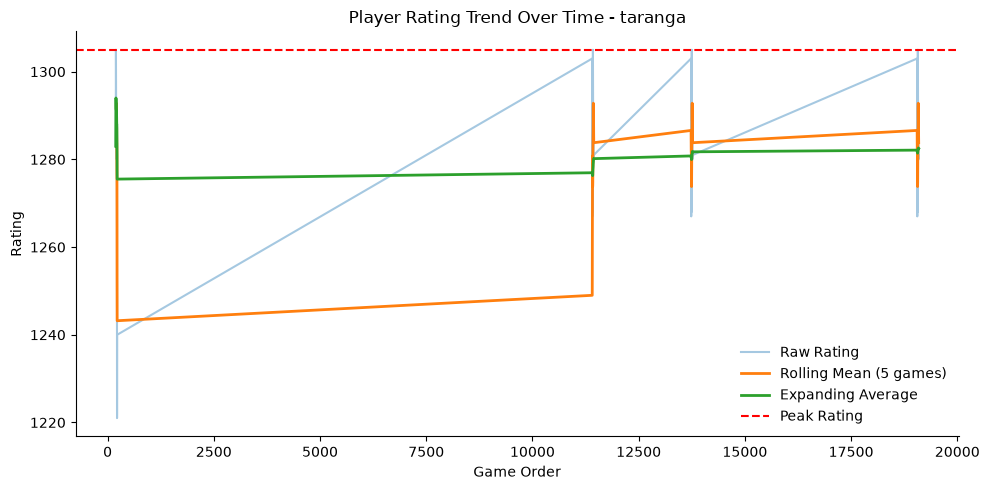

In [17]:
# Create figure for visualization
fig, ax = plt.subplots(figsize=(10, 5))

# Plot raw rating (noisy data)
ax.plot(player_df.index, player_df['white_rating'],
        alpha=0.4, label='Raw Rating')

# Plot rolling average (smoothed short-term trend)
ax.plot(player_df.index, player_df['rolling_5'],
        linewidth=2, label='Rolling Mean (5 games)')

# Plot expanding average (long-term trend)
ax.plot(player_df.index, player_df['expanding_avg'],
        linewidth=2, label='Expanding Average')

# Highlight highest rating point
ax.axhline(y=max_rating_game['white_rating'],
           color='red', linestyle='--',
           label='Peak Rating')

# Title and labels
ax.set_title(f"Player Rating Trend Over Time - {selected_player}")
ax.set_xlabel("Game Order")
ax.set_ylabel("Rating")

# Clean style
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)

# Layout fix
fig.tight_layout()

# Save figure
plt.savefig("../images/plots/AQ2_rolling_analysis.png",
            dpi=150, bbox_inches="tight")

# Show plot
plt.show()

In [18]:
# AQ3: Temperature time-series
# Keep only GISTEMP data (NASA dataset)
gistemp = temp_df[temp_df['Source'] == 'GISTEMP'].copy()

# Check structure
gistemp.head()

,Source,Year,Mean
360,GISTEMP,1880-01,-0.19
362,GISTEMP,1880-02,-0.25
364,GISTEMP,1880-03,-0.10
366,GISTEMP,1880-04,-0.17
368,GISTEMP,1880-05,-0.10


In [19]:
# Create 10-year rolling mean to smooth temperature fluctuations
gistemp['rolling_10'] = gistemp['Mean'].rolling(window=10, min_periods=1).mean()

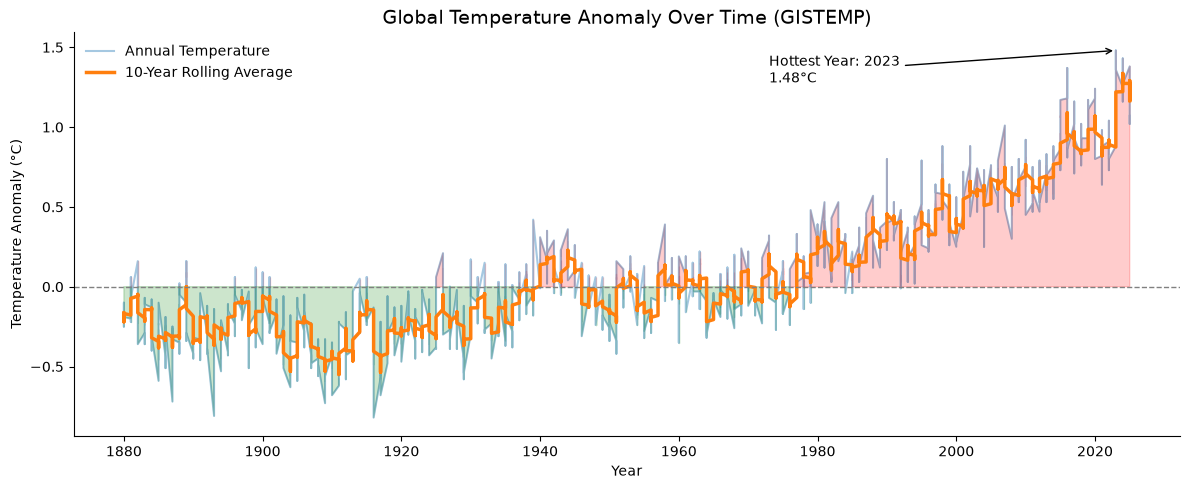

In [23]:
# AQ3: Global Temperature Analysis

gistemp = temp_df[temp_df["Source"] == "GISTEMP"].copy()

# Convert Year column to proper datetime
gistemp["Year"] = pd.to_datetime(gistemp["Year"])

# Extract numeric year (IMPORTANT FIX)
gistemp["Year_num"] = gistemp["Year"].dt.year

# Sort values
gistemp = gistemp.sort_values("Year_num")

# Rolling average (10-year smoothing)
gistemp["rolling_10"] = gistemp["Mean"].rolling(window=10, min_periods=1).mean()

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

# Raw data (noisy signal)
ax.plot(
    gistemp["Year_num"],
    gistemp["Mean"],
    alpha=0.4,
    label="Annual Temperature"
)

# Smoothed trend
ax.plot(
    gistemp["Year_num"],
    gistemp["rolling_10"],
    linewidth=2.5,
    label="10-Year Rolling Average"
)

# Baseline (0 anomaly)
ax.axhline(y=0, color="grey", linestyle="--", linewidth=1)

# Fill positive anomalies (warming)
ax.fill_between(
    gistemp["Year_num"], 0, gistemp["Mean"],
    where=gistemp["Mean"] > 0,
    color="red",
    alpha=0.2
)

# Fill negative anomalies (cooling)
ax.fill_between(
    gistemp["Year_num"], 0, gistemp["Mean"],
    where=gistemp["Mean"] <= 0,
    color="green",
    alpha=0.2
)

# Find hottest year
hottest = gistemp.loc[gistemp["Mean"].idxmax()]

# Annotation (IMPORTANT for grading)
ax.annotate(
    f"Hottest Year: {hottest['Year_num']}\n{hottest['Mean']:.2f}°C",
    xy=(hottest["Year_num"], hottest["Mean"]),
    xytext=(hottest["Year_num"] - 50, hottest["Mean"] - 0.2),
    arrowprops=dict(arrowstyle="->", color="black")
)

# Titles & labels
ax.set_title("Global Temperature Anomaly Over Time (GISTEMP)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Temperature Anomaly (°C)")

# Clean style
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)

# Layout fix (IMPORTANT ORDER)
fig.tight_layout()

# Save figure
plt.savefig(
    "../images/plots/AQ3_temperature.png",
    dpi=150,
    bbox_inches="tight"
)

# Show plot
plt.show()

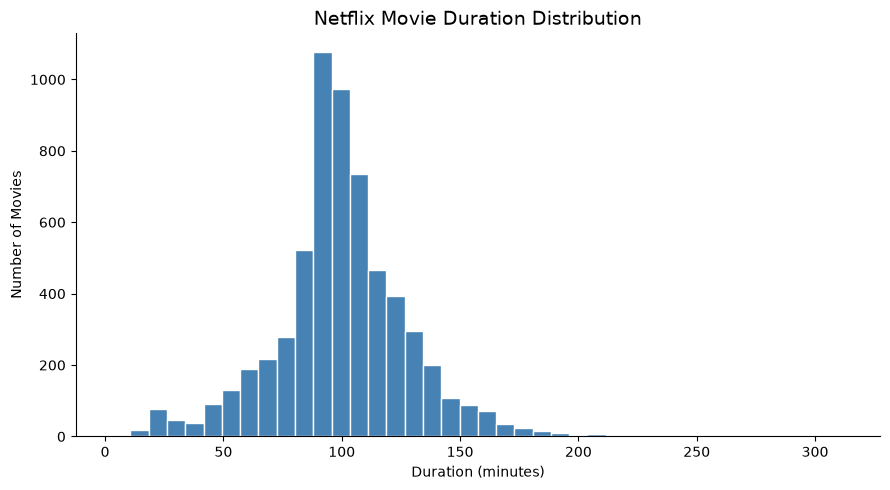

In [25]:
# QA4: Movie Duration Distribution

# Filter only movies
movies = netflix_df[netflix_df["type"] == "Movie"].copy()

# Clean duration column (remove "min")
movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

# Create plot
fig, ax = plt.subplots(figsize=(9,5))

# Histogram
ax.hist(
    movies["duration"].dropna(),
    bins=40,
    color="steelblue",
    edgecolor="white"
)

# Title + labels
ax.set_title("Netflix Movie Duration Distribution", fontsize=14)
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of Movies")

# Clean style
ax.spines[['top','right']].set_visible(False)

# Save
fig.tight_layout()
plt.savefig("../images/plots/AQ4_duration_hist.png", dpi=150, bbox_inches="tight")
plt.show()

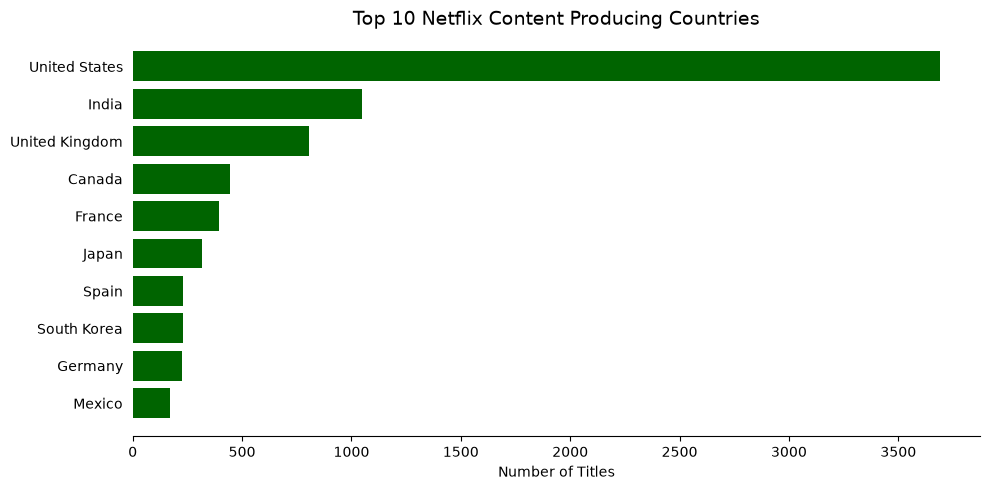

In [26]:
# AQ4:Top 10 Countries

# Clean country column (split multi-country values)
countries = netflix_df["country"].dropna().str.split(", ").explode()

# Count top 10
top10 = countries.value_counts().head(10)

# Plot
fig, ax = plt.subplots(figsize=(10,5))

ax.barh(
    top10.index[::-1],
    top10.values[::-1],
    color="darkgreen"
)

# Labels
ax.set_title("Top 10 Netflix Content Producing Countries", fontsize=14)
ax.set_xlabel("Number of Titles")

# Clean style
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)

# Save
fig.tight_layout()
plt.savefig("../images/plots/AQ4_top_countries.png", dpi=150, bbox_inches="tight")
plt.show()

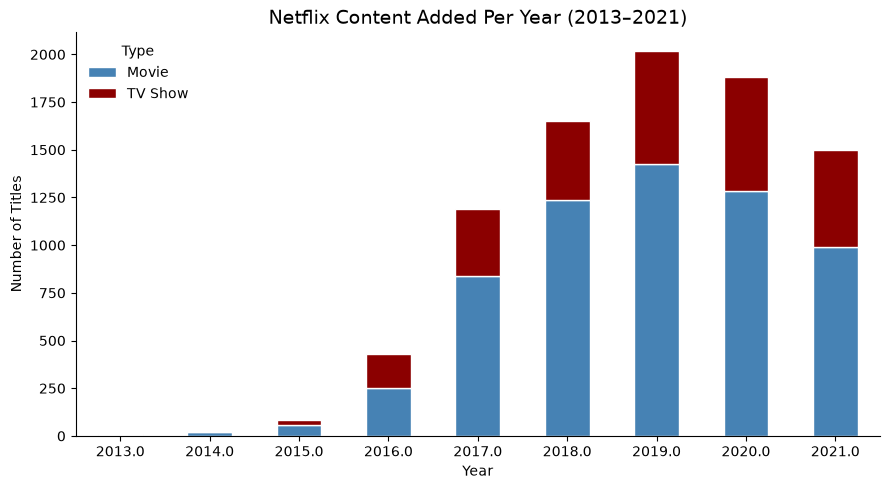

In [27]:
# AQ4: Stacked Bar (Content Over Years)

# Extract year added
netflix_df["year_added"] = pd.to_datetime(
    netflix_df["date_added"].str.strip(),
    errors="coerce"
).dt.year

# Filter years
filtered = netflix_df[
    netflix_df["year_added"].between(2013, 2021)
]

# Group by year + type
grouped = filtered.groupby(["year_added", "type"]).size().reset_index(name="count")

# Pivot table
wide = grouped.pivot(
    index="year_added",
    columns="type",
    values="count"
).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(9,5))

wide.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["steelblue", "darkred"],
    edgecolor="white"
)

# Titles
ax.set_title("Netflix Content Added Per Year (2013–2021)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Titles")

ax.tick_params(axis='x', rotation=0)

# Clean style
ax.spines[['top','right']].set_visible(False)
ax.legend(title="Type", frameon=False)

# Save
fig.tight_layout()
plt.savefig("../images/plots/AQ4_stacked_bar.png", dpi=150, bbox_inches="tight")
plt.show()

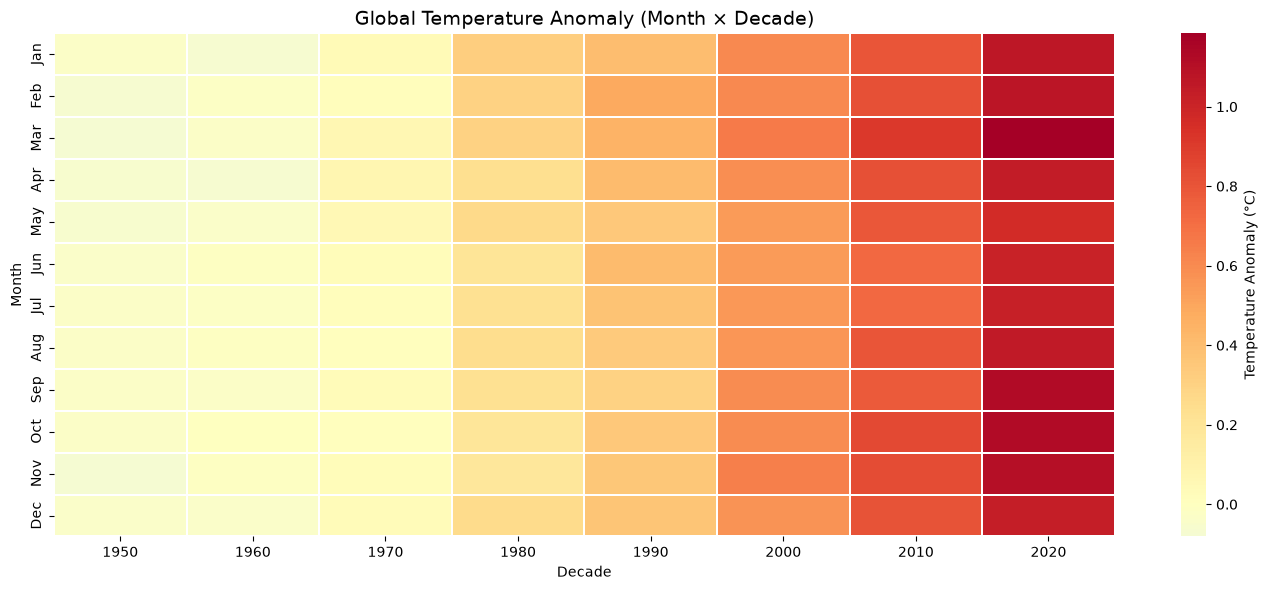

In [28]:
# AQ5: Temperature Heatmap (Month × Decade)
# Filter GISTEMP only
gm = temp_df[temp_df["Source"] == "GISTEMP"].copy()

# Convert Year column to datetime
# Important because format is like "1850-01"
gm["date"] = pd.to_datetime(gm["Year"])

# Extract year + month + decade
gm["year"] = gm["date"].dt.year
gm["month"] = gm["date"].dt.month
gm["decade"] = (gm["year"] // 10) * 10

# Filter years >= 1950 (as required)
gm = gm[gm["year"] >= 1950]

# Create pivot table (IMPORTANT STEP)
# rows = months | columns = decades | values = temperature mean

pivot = gm.pivot_table(
    index="month",
    columns="decade",
    values="Mean",
    aggfunc="mean"
)

# Replace month numbers with names
pivot.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

# Create figure
fig, ax = plt.subplots(figsize=(14,6))

# Heatmap (MAIN VISUAL)
sns.heatmap(
    pivot,
    cmap="RdYlBu_r",     # diverging palette (cool → warm)
    center=0,            # important for anomalies
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Temperature Anomaly (°C)"}
)

# Titles
ax.set_title("Global Temperature Anomaly (Month × Decade)", fontsize=14)
ax.set_xlabel("Decade")
ax.set_ylabel("Month")

# Clean style
ax.spines[['top','right']].set_visible(False)

# Save figure (IMPORTANT for marks)
fig.tight_layout()
plt.savefig(
    "../images/plots/AQ5_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()